In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor

In [ ]:
data_path = "../data/processed/mieszkania_clean.csv"

df = pd.read_csv(data_path)

if "year_month" in df.columns:
    df["year_month"] = pd.to_datetime(df["year_month"])

print("Liczba rekordów:", df.shape[0])
print("Liczba kolumn:", df.shape[1])

df.head()

Liczba rekordów: 160974
Liczba kolumn: 36


,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,hasStorageRoom,price,source_file,year_month,price_per_m2,relative_floor,m2_per_room,is_top_floor,is_ground_floor,building_height
0,f8524536d4b09a0c8ccc0197ec9d7bde,szczecin,blockOfFlats,63.00,3,4,10,1980.0,53.378933,14.625296,...,yes,415000.0,apartments_pl_2023_08.csv,2023-08-01,6587.301587,0.400000,21.00,0,0,wysoki
1,accbe77d4b360fea9735f138a50608dd,szczecin,blockOfFlats,36.00,2,8,10,NaN,53.442692,14.559690,...,yes,395995.0,apartments_pl_2023_08.csv,2023-08-01,10999.861111,0.800000,18.00,0,0,wysoki
2,8373aa373dbc3fe7ca3b7434166b8766,szczecin,tenement,73.02,3,2,3,NaN,53.452222,14.553333,...,no,565000.0,apartments_pl_2023_08.csv,2023-08-01,7737.606135,0.666667,24.34,0,0,niski
3,0a68cd14c44ec5140143ece75d739535,szczecin,tenement,87.60,3,2,3,NaN,53.435100,14.532900,...,yes,640000.0,apartments_pl_2023_08.csv,2023-08-01,7305.936073,0.666667,29.20,0,0,niski
4,f66320e153c2441edc0fe293b54c8aeb,szczecin,blockOfFlats,66.00,3,1,3,NaN,53.410278,14.503611,...,no,759000.0,apartments_pl_2023_08.csv,2023-08-01,11500.000000,0.333333,22.00,0,1,niski


In [4]:
print("Dostępne kolumny:")
print(df.columns.tolist())

Dostępne kolumny:
['id', 'city', 'type', 'squareMeters', 'rooms', 'floor', 'floorCount', 'buildYear', 'latitude', 'longitude', 'centreDistance', 'poiCount', 'schoolDistance', 'clinicDistance', 'postOfficeDistance', 'kindergartenDistance', 'restaurantDistance', 'collegeDistance', 'pharmacyDistance', 'ownership', 'buildingMaterial', 'condition', 'hasParkingSpace', 'hasBalcony', 'hasElevator', 'hasSecurity', 'hasStorageRoom', 'price', 'source_file', 'year_month', 'price_per_m2', 'relative_floor', 'm2_per_room', 'is_top_floor', 'is_ground_floor', 'building_height']


In [ ]:
df_model = df.copy()

if "id" in df_model.columns and "year_month" in df_model.columns:
    df_model = df_model.sort_values("year_month").drop_duplicates("id", keep="last")
elif "id" in df_model.columns:
    df_model = df_model.drop_duplicates("id", keep="last")

print("Liczba rekordów po usunięciu powtarzających się ofert:", df_model.shape[0])

Liczba rekordów po usunięciu powtarzających się ofert: 77055


In [ ]:
features = [
    "city",
    "squareMeters",
    "rooms",
    "floor",
    "floorCount",
    "buildYear",
    "centreDistance",
    "poiCount"
]

target = "price"

missing_cols = [col for col in features + [target] if col not in df_model.columns]

if missing_cols:
    print("Brakuje kolumn:", missing_cols)
else:
    print("Wszystkie potrzebne kolumny są dostępne.")

Wszystkie potrzebne kolumny są dostępne.


In [8]:
df_model = df_model.dropna(subset=features + [target]).copy()

print("Liczba rekordów po usunięciu braków w kolumnach modelowych:", df_model.shape[0])

X = df_model[features]
y = df_model[target]

X.head()

Liczba rekordów po usunięciu braków w kolumnach modelowych: 64448


,city,squareMeters,rooms,floor,floorCount,buildYear,centreDistance,poiCount
0,szczecin,63.00,3,4,10,1980.0,6.53,9.0
10304,warszawa,47.38,2,4,7,1960.0,0.48,63.0
10308,warszawa,53.10,2,3,4,1962.0,3.87,26.0
10309,warszawa,61.00,3,11,12,1977.0,7.31,18.0
10314,warszawa,67.00,3,2,2,1934.0,4.17,36.0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Liczba rekordów treningowych:", X_train.shape[0])
print("Liczba rekordów testowych:", X_test.shape[0])

Liczba rekordów treningowych: 51558
Liczba rekordów testowych: 12890


In [10]:
numeric_features = [
    "squareMeters",
    "rooms",
    "floor",
    "floorCount",
    "buildYear",
    "centreDistance",
    "poiCount"
]

categorical_features = ["city"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", XGBRegressor(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            objective="reg:squarederror"
        ))
    ]
)

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [11]:
model.fit(X_train, y_train)

print("Model został wytrenowany.")

Model został wytrenowany.


In [12]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Wyniki modelu:")
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:,.2f} zł")
print(f"RMSE: {rmse:,.2f} zł")

Wyniki modelu:
R²: 0.8544
MAE: 103,108.41 zł
RMSE: 154,763.37 zł


In [13]:
results = X_test.copy()
results["cena_rzeczywista"] = y_test.values
results["cena_przewidywana"] = y_pred
results["roznica"] = results["cena_rzeczywista"] - results["cena_przewidywana"]
results["roznica_proc"] = results["roznica"] / results["cena_przewidywana"] * 100

results.head(10)

,city,squareMeters,rooms,floor,floorCount,buildYear,centreDistance,poiCount,cena_rzeczywista,cena_przewidywana,roznica,roznica_proc
114285,poznan,64.37,3,1,6,2023.0,2.11,7.0,879000.0,847012.12500,31987.87500,3.776555
147312,poznan,67.70,3,4,4,2023.0,4.96,6.0,679000.0,819463.25000,-140463.25000,-17.140885
141146,warszawa,46.50,3,2,4,1974.0,4.63,17.0,856000.0,770306.62500,85693.37500,11.124580
101661,wroclaw,29.62,1,4,7,2022.0,2.56,26.0,620000.0,552668.68750,67331.31250,12.182943
152073,lodz,54.00,2,1,4,1991.0,5.64,6.0,470000.0,411687.68750,58312.31250,14.164211
145911,krakow,37.80,2,6,10,1976.0,6.95,19.0,567000.0,519314.65625,47685.34375,9.182360
152333,lodz,57.29,3,2,4,1975.0,5.46,18.0,460000.0,433534.90625,26465.09375,6.104490
10517,warszawa,52.70,2,3,4,1957.0,3.37,13.0,750000.0,885822.93750,-135822.93750,-15.332967
32653,poznan,35.00,1,5,6,2007.0,2.57,20.0,420000.0,472203.81250,-52203.81250,-11.055356
48894,wroclaw,39.40,2,1,8,1975.0,1.86,29.0,450000.0,519126.37500,-69126.37500,-13.315905


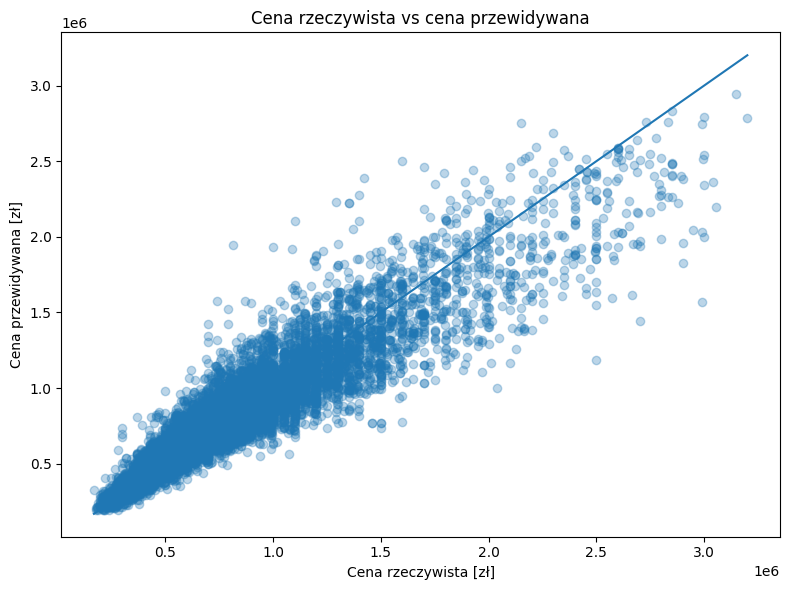

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.3)

min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot([min_price, max_price], [min_price, max_price])

plt.title("Cena rzeczywista vs cena przewidywana")
plt.xlabel("Cena rzeczywista [zł]")
plt.ylabel("Cena przewidywana [zł]")

plt.tight_layout()

os.makedirs("../figures", exist_ok=True)
plt.savefig("../figures/model_cena_rzeczywista_vs_przewidywana.png", dpi=300)

plt.show()

In [15]:
def ocen_oferte(cena_ofertowa, cena_modelowa):
    roznica_proc = (cena_ofertowa - cena_modelowa) / cena_modelowa * 100

    if roznica_proc < -10:
        ocena = "okazja cenowa"
    elif roznica_proc <= 10:
        ocena = "cena rynkowa"
    else:
        ocena = "oferta droga"

    return roznica_proc, ocena

In [16]:
sample_offer = X_test.iloc[[0]]
real_price = y_test.iloc[0]

predicted_price = model.predict(sample_offer)[0]

roznica_proc, ocena = ocen_oferte(real_price, predicted_price)

print("Przykładowa oferta:")
display(sample_offer)

print(f"Cena rzeczywista: {real_price:,.2f} zł")
print(f"Cena przewidywana przez model: {predicted_price:,.2f} zł")
print(f"Różnica procentowa: {roznica_proc:.2f}%")
print(f"Ocena oferty: {ocena}")

Przykładowa oferta:


,city,squareMeters,rooms,floor,floorCount,buildYear,centreDistance,poiCount
114285,poznan,64.37,3,1,6,2023.0,2.11,7.0


Cena rzeczywista: 879,000.00 zł
Cena przewidywana przez model: 847,012.12 zł
Różnica procentowa: 3.78%
Ocena oferty: cena rynkowa


In [17]:
os.makedirs("../data/processed", exist_ok=True)

results_path = "../data/processed/wyniki_modelu.csv"

results.to_csv(results_path, index=False)

print(f"Wyniki zapisane w: {results_path}")

Wyniki zapisane w: ../data/processed/wyniki_modelu.csv


In [18]:
summary = pd.DataFrame({
    "Metryka": ["R²", "MAE", "RMSE", "Liczba obserwacji w modelu"],
    "Wartość": [
        round(r2, 4),
        round(mae, 2),
        round(rmse, 2),
        len(df_model)
    ]
})

summary

,Metryka,Wartość
0,R²,0.8544
1,MAE,103108.4100
2,RMSE,154763.3700
3,Liczba obserwacji w modelu,64448.0000
